# Build an RNN model to predict the next number in a sequence and observe the limitations of RNNs. 

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

print("torch version:", torch.__version__)

torch version: 2.9.1+cpu


## generating the sequence data


In [2]:
# create sequence: 1 to 50
sequence = list(range(1, 51))
print("full sequence:", sequence)

window_size = 4  # how many past numbers to use as input

def make_dataset(seq, window):
    X, y = [], []
    for i in range(len(seq) - window):
        X.append(seq[i:i+window])
        y.append(seq[i+window])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X, y = make_dataset(sequence, window_size)

print(f"\ndataset shape: X={X.shape}, y={y.shape}")
print("first 3 samples:")
for i in range(3):
    print(f"  input: {X[i]}  →  target: {y[i]}")

full sequence: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]

dataset shape: X=(46, 4), y=(46,)
first 3 samples:
  input: [1. 2. 3. 4.]  →  target: 5.0
  input: [2. 3. 4. 5.]  →  target: 6.0
  input: [3. 4. 5. 6.]  →  target: 7.0


## normalize the data

In [3]:
max_val = max(sequence)

X_norm = X / max_val
y_norm = y / max_val

# convert to tensors — RNN expects shape (batch, seq_len, features)
X_tensor = torch.tensor(X_norm).unsqueeze(-1)  # → (46, 4, 1)
y_tensor = torch.tensor(y_norm).unsqueeze(-1)  # → (46, 1)

print("X_tensor shape:", X_tensor.shape)
print("y_tensor shape:", y_tensor.shape)

X_tensor shape: torch.Size([46, 4, 1])
y_tensor shape: torch.Size([46, 1])


## defining the RNN model



In [4]:
class SimpleRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super(SimpleRNN, self).__init__()
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True  # input shape: (batch, seq, feature)
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, hidden = self.rnn(x)   # out: (batch, seq_len, hidden_size)
        last = out[:, -1, :]        # take only last timestep's output
        result = self.fc(last)
        return result


model = SimpleRNN(input_size=1, hidden_size=32, num_layers=1)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\ntotal parameters: {total_params}")

SimpleRNN(
  (rnn): RNN(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

total parameters: 1153


## training loop


In [5]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

num_epochs = 300
loss_history = []

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    output = model(X_tensor)        # forward pass
    loss = criterion(output, y_tensor)

    loss.backward()                 # backprop
    optimizer.step()

    loss_history.append(loss.item())

    if (epoch + 1) % 50 == 0:
        print(f"epoch {epoch+1:>3}/{num_epochs}  |  loss: {loss.item():.6f}")

print("\ntraining done")

epoch  50/300  |  loss: 0.000743
epoch 100/300  |  loss: 0.000111
epoch 150/300  |  loss: 0.000079
epoch 200/300  |  loss: 0.000059
epoch 250/300  |  loss: 0.000044
epoch 300/300  |  loss: 0.000033

training done


## loss curve

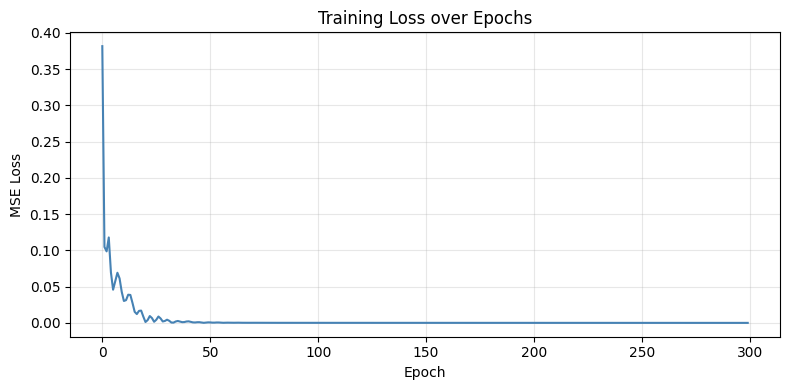

In [6]:
plt.figure(figsize=(8, 4))
plt.plot(loss_history, color='steelblue')
plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## predictions vs actual

In [7]:
model.eval()
with torch.no_grad():
    preds_norm = model(X_tensor).squeeze().numpy()

# scale back to original range
preds = preds_norm * max_val
actual = y

print(f"{'input':<25}  {'actual':>8}  {'predicted':>10}  {'error':>8}")
print("-" * 58)
for i in range(10):
    inp = str(list(X[i].astype(int)))
    err = abs(actual[i] - preds[i])
    print(f"{inp:<25}  {actual[i]:>8.0f}  {preds[i]:>10.2f}  {err:>8.4f}")

input                        actual   predicted     error
----------------------------------------------------------
[np.int64(1), np.int64(2), np.int64(3), np.int64(4)]         5        4.67    0.3317
[np.int64(2), np.int64(3), np.int64(4), np.int64(5)]         6        5.68    0.3177
[np.int64(3), np.int64(4), np.int64(5), np.int64(6)]         7        6.70    0.3002
[np.int64(4), np.int64(5), np.int64(6), np.int64(7)]         8        7.72    0.2795
[np.int64(5), np.int64(6), np.int64(7), np.int64(8)]         9        8.74    0.2559
[np.int64(6), np.int64(7), np.int64(8), np.int64(9)]        10        9.77    0.2297
[np.int64(7), np.int64(8), np.int64(9), np.int64(10)]        11       10.80    0.2013
[np.int64(8), np.int64(9), np.int64(10), np.int64(11)]        12       11.83    0.1709
[np.int64(9), np.int64(10), np.int64(11), np.int64(12)]        13       12.86    0.1389
[np.int64(10), np.int64(11), np.int64(12), np.int64(13)]        14       13.89    0.1055


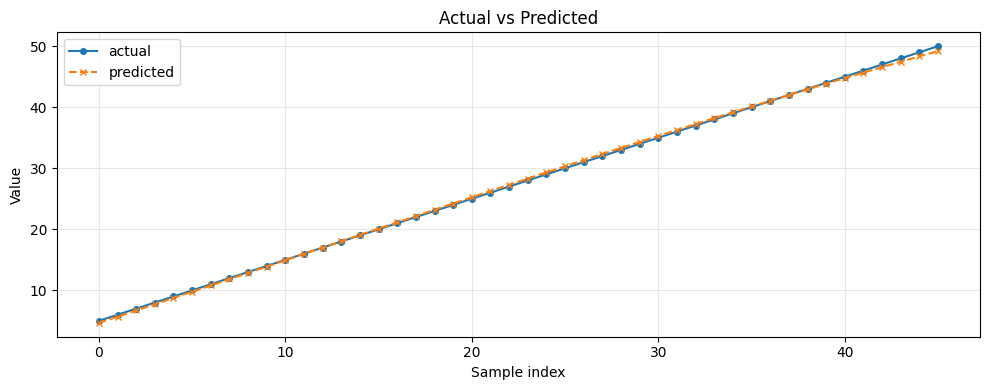

In [8]:
plt.figure(figsize=(10, 4))
plt.plot(actual, label='actual', marker='o', markersize=4)
plt.plot(preds,  label='predicted', marker='x', markersize=4, linestyle='--')
plt.title("Actual vs Predicted")
plt.xlabel("Sample index")
plt.ylabel("Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## testing on unseen values


In [9]:
def predict_next(model, last_n_numbers, max_val):
    arr = np.array(last_n_numbers, dtype=np.float32) / max_val
    t = torch.tensor(arr).unsqueeze(0).unsqueeze(-1)  # (1, seq_len, 1)
    model.eval()
    with torch.no_grad():
        pred = model(t).item() * max_val
    return pred


test_cases = [
    [10, 11, 12, 13],   # expected: 14
    [20, 21, 22, 23],   # expected: 24
    [47, 48, 49, 50],   # expected: 51  (extrapolation)
    [100, 101, 102, 103],  # far out of range
]

print(f"{'input':<25}  {'expected':>10}  {'predicted':>10}")
print("-" * 50)
for tc in test_cases:
    expected = tc[-1] + 1
    pred = predict_next(model, tc, max_val)
    print(f"{str(tc):<25}  {expected:>10}  {pred:>10.2f}")

input                        expected   predicted
--------------------------------------------------
[10, 11, 12, 13]                   14       13.89
[20, 21, 22, 23]                   24       24.23
[47, 48, 49, 50]                   51       50.06
[100, 101, 102, 103]              104       82.70


## RNN limitations 

### Limitation 1: vanishing gradient on long sequences


In [ ]:
def train_with_window(window, epochs=300, hidden=32):
    Xw, yw = make_dataset(sequence, window)
    max_v = max(sequence)
    Xw_n = Xw / max_v
    yw_n = yw / max_v
    Xt = torch.tensor(Xw_n).unsqueeze(-1)
    yt = torch.tensor(yw_n).unsqueeze(-1)

    m = SimpleRNN(input_size=1, hidden_size=hidden)
    opt = torch.optim.Adam(m.parameters(), lr=0.01)
    crit = nn.MSELoss()
    losses = []

    for _ in range(epochs):
        m.train()
        opt.zero_grad()
        out = m(Xt)
        loss = crit(out, yt)
        loss.backward()
        opt.step()
        losses.append(loss.item())

    return losses


print("training with different window sizes...")
windows = [2, 4, 8, 15]
results = {}
for w in windows:
    losses = train_with_window(w)
    results[w] = losses
    print(f"  window={w:>2}  →  final loss: {losses[-1]:.6f}")


training with different window sizes...
  window= 2  →  final loss: 0.000060
  window= 4  →  final loss: 0.000033
  window= 8  →  final loss: 0.000014
  window=15  →  final loss: 0.000001
done


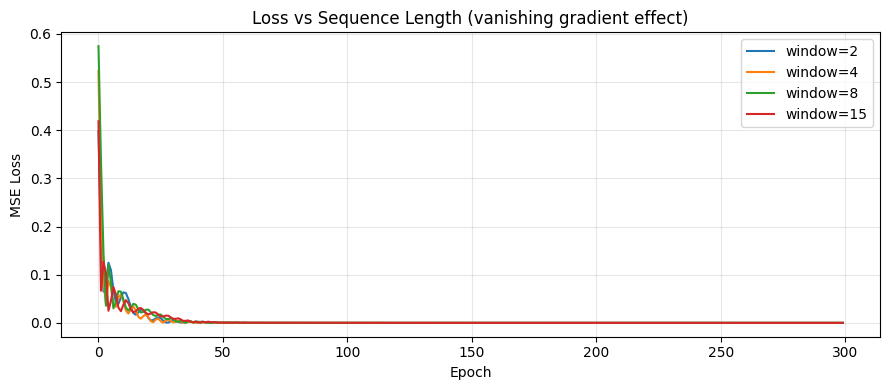


observation: longer window → higher final loss
gradients have to travel further back → they vanish before reaching early timesteps
this is the vanishing gradient problem in RNNs


In [11]:
plt.figure(figsize=(9, 4))
for w, losses in results.items():
    plt.plot(losses, label=f"window={w}")
plt.title("Loss vs Sequence Length (vanishing gradient effect)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nobservation: longer window → higher final loss")
print("gradients have to travel further back → they vanish before reaching early timesteps")
print("this is the vanishing gradient problem in RNNs")

### Limitation 2: struggles with non-linear / noisy sequences


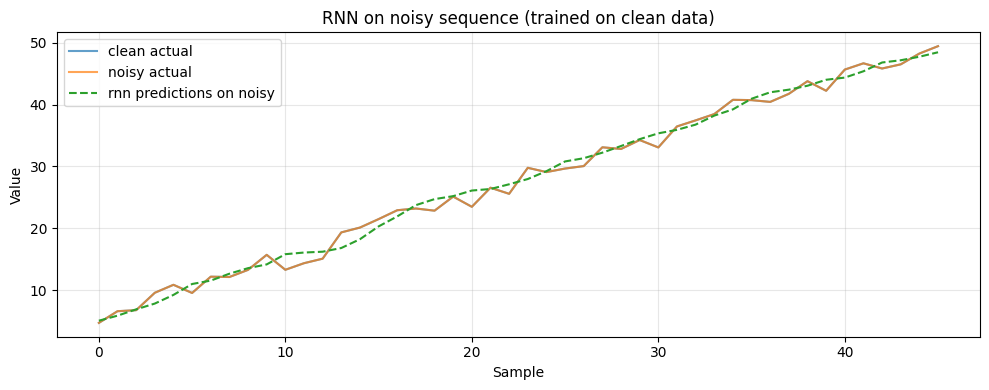

MSE on clean sequence : 0.0827
MSE on noisy sequence : 1.6511

RNN overfits clean patterns and struggles to generalize to noise


In [12]:
np.random.seed(0)
noisy_seq = [i + np.random.uniform(-2, 2) for i in range(1, 51)]

Xn, yn = make_dataset(noisy_seq, window_size)
Xn_norm = np.array(Xn, dtype=np.float32) / max_val
yn_norm = np.array(yn, dtype=np.float32) / max_val
Xn_t = torch.tensor(Xn_norm).unsqueeze(-1)
yn_t = torch.tensor(yn_norm).unsqueeze(-1)

model.eval()
with torch.no_grad():
    noisy_preds = model(Xn_t).squeeze().numpy() * max_val

plt.figure(figsize=(10, 4))
plt.plot(yn, label='clean actual', alpha=0.7)
plt.plot(yn_norm * max_val, label='noisy actual', alpha=0.7)
plt.plot(noisy_preds, label='rnn predictions on noisy', linestyle='--')
plt.title("RNN on noisy sequence (trained on clean data)")
plt.xlabel("Sample")
plt.ylabel("Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

mse_clean = np.mean((model(X_tensor).detach().squeeze().numpy() * max_val - y) ** 2)
mse_noisy = np.mean((noisy_preds - yn) ** 2)
print(f"MSE on clean sequence : {mse_clean:.4f}")
print(f"MSE on noisy sequence : {mse_noisy:.4f}")
print("\nRNN overfits clean patterns and struggles to generalize to noise")

## summary

**what worked:**
- RNN learns arithmetic sequences pretty well when sequence length is short
- predictions are close to actual values for in-distribution inputs

**limitations observed:**

1. **Vanishing gradient** — as window size increases from 2 → 15, the training loss gets worse. the RNN can't maintain information over long distances because gradients shrink during backprop through time (BPTT)

2. **Generalization** — the model was trained on a clean sequence so it fits that pattern very tightly. when the same sequence has noise added, predictions get worse because the model memorized the exact pattern

3. **Extrapolation** — for inputs way outside the training range (like [100,101,102,103]), predictions are off because the model hasn't seen those scales
